# **Segmentação de Clientes - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

In [ ]:
# Importar Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix


    

In [ ]:
# Configuracoes iniciais
df = pd.read_csv('Mall_Customers.csv')
# Ajuste de display (opcional)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)



In [ ]:
#  Inspecionar  dados 
print(">> Primeiras 5 linhas:")
print(df.head(), "\n")

print(">> Info geral do DataFrame:")
df.info()
print()


>> Primeiras 5 linhas:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40 

>> Info geral do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB



In [ ]:
# estatisticas descritivas 
print(">> Estatísticas descritivas (numéricas):")
print(df.describe(), "\n")

print(">> Estatísticas descritivas (tudo):")
print(df.describe(include='all'), "\n")


>> Estatísticas descritivas (numéricas):
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000 

>> Estatísticas descritivas (tudo):
        CustomerID  Gender         Age  Annual Income (k$)  Spending Score (1-100)
count   200.000000     200  200.000000          200.000000              200.000000
unique         NaN       2         NaN                 NaN                     NaN
top   

R: As primeiras 5 linhas confirmam que cada cliente é único e que não há colunas extras ou faltantes evidentes. A estatistica descritiva numericas com idade variando de 18 a 70 anos, com média ~38,8 e desvio ~14. Renda anual entre 15k$ e 137k$, média ~60,6k$. Spending Score de 1 a 99, média ~50,2.

Conclui-se que há ampla dispersão em todas as métricas, o que sugere potencial para segmentação (ex.: faixas de idade e de renda distintas).



In [ ]:
#  Checagem de valores ausentes
na_counts = df.isnull().sum() 
na_pct = (na_counts / len(df) * 100).round(2) 
missing_df = pd.DataFrame({
    'missing_count': na_counts,
    'missing_pct': na_pct
})
print(">> Valores ausentes por coluna:")
print(missing_df, "\n")


>> Valores ausentes por coluna:
                        missing_count  missing_pct
CustomerID                          0          0.0
Gender                              0          0.0
Age                                 0          0.0
Annual Income (k$)                  0          0.0
Spending Score (1-100)              0          0.0 



R: 0 faltantes, nao havendo necessidade de imputação nem descarte de linhas, avançamos diretamente para a parte descritiva e visual.



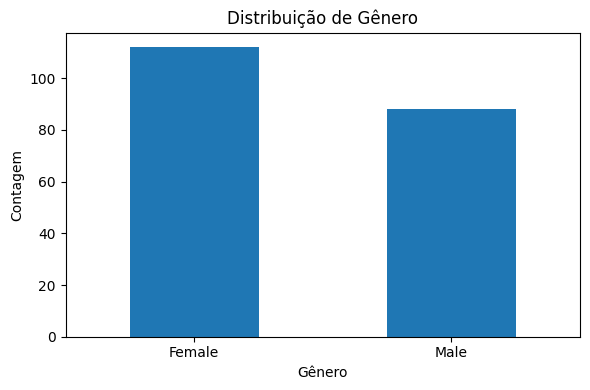

In [ ]:
#  Distribuicao categorica
plt.figure(figsize=(6,4))
df['Gender'].value_counts().plot(kind='bar', rot=0)
plt.title('Distribuição de Gênero')       
plt.xlabel('Gênero')                     
plt.ylabel('Contagem')                   
plt.tight_layout()                       
plt.show()                              




R: 112 clientes femininos (56%) e 88 masculinos (44%). Leve predominância de mulheres na base; qualquer modelo ou segmento deve levar em conta esse desequilíbrio moderado.

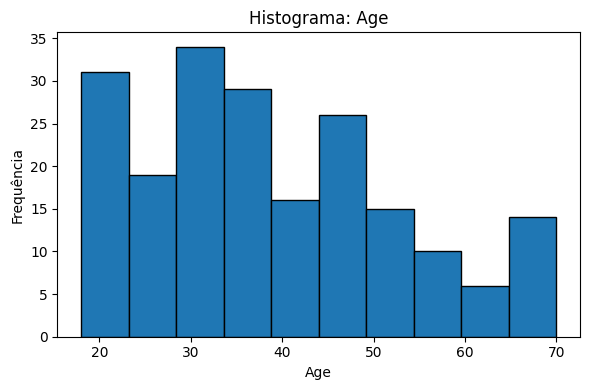

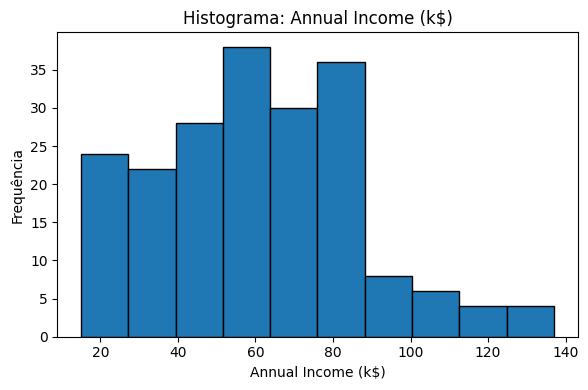

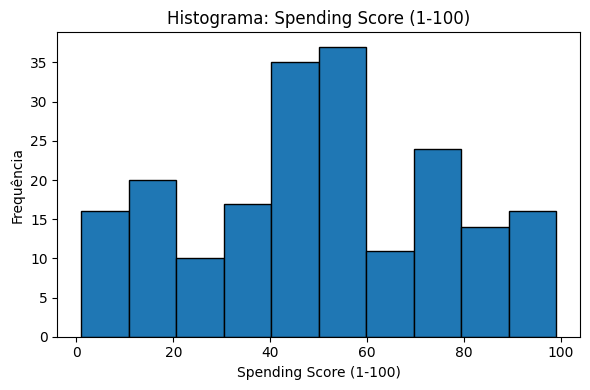

In [ ]:
# Histogramas 
num_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=10, edgecolor='black')  
    plt.title(f'Histograma: {col}')                         
    plt.xlabel(col)                                         
    plt.ylabel('Frequência')                                
    plt.tight_layout()                                      
    plt.show()                                              


R: 

Idade com concentração forte entre 20 e 40 anos, caindo para as faixas mais altas; poucos clientes abaixo de 20 e acima de 60.
Renda Anual: pico claro na faixa 40–80 k$, com cauda à direita até 137 k$ (alguns clientes de alta renda).
Spending Score: distribuição relativamente uniforme ao longo das pontuações, sem picos extremos, indicando perfis de “alto” e “baixo” gasto bem distribuídos.

Os clientes jovens-adultos são o público-alvo majoritário, onde há uma minoria de “top spenders” em renda, mas o gasto em si (score) não segue exatamente a mesma dispersão da renda.

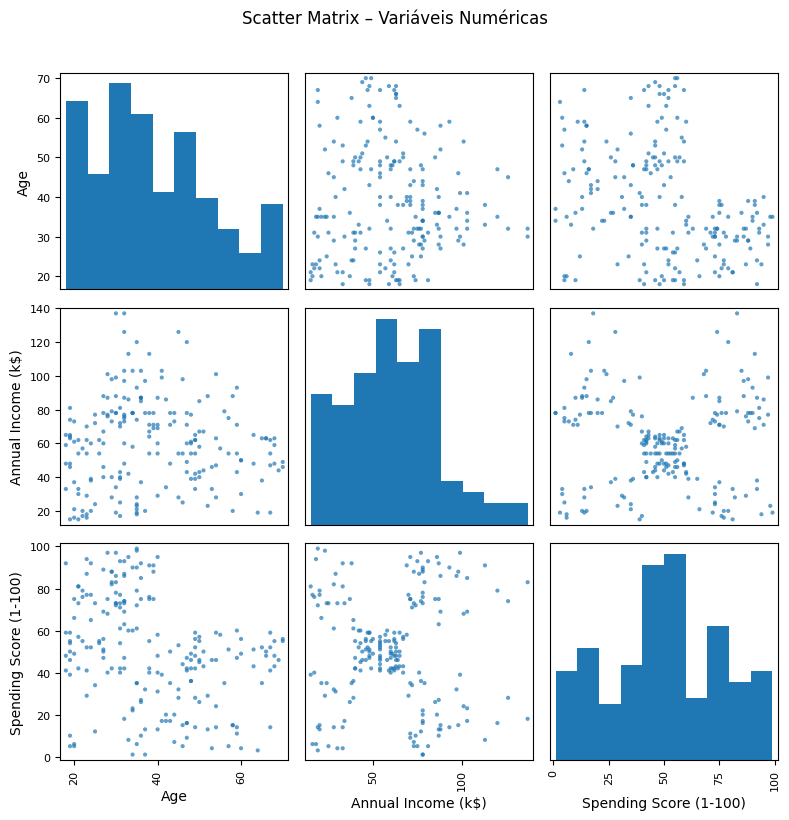

In [ ]:
# Scatter Matrix 
scatter_matrix(df[num_cols], diagonal='hist', alpha=0.7, figsize=(8,8))
plt.suptitle('Scatter Matrix – Variáveis Numéricas', y=1.02)  
plt.tight_layout()                                           
plt.show()                                                    


Relações visuais:

Age × Annual Income: nuvem de pontos sem padrão claro (sem correlação linear).

Age × Spending Score: leve tendência negativa — clientes mais velhos tendem a ter score ligeiramente menor.

Income × Spending Score: nuvem fechada, sem relação aparente.

 A clusterização por renda não agrupa automaticamente os “bons gastadores”; já a idade parece influenciar (quanto mais jovem, maior propensão a gastar).

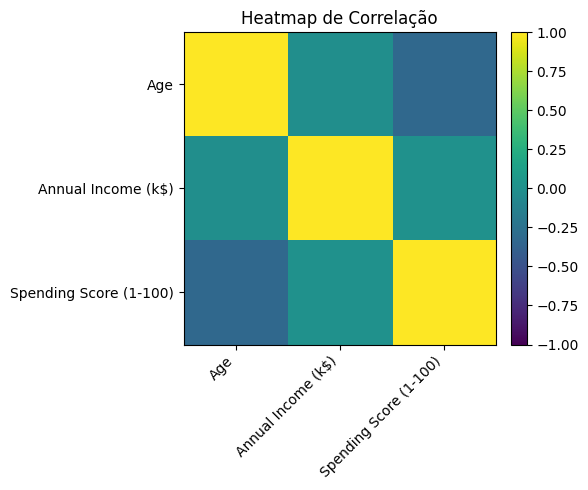

In [ ]:
# Heatmap de correlacao
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
im = plt.imshow(corr, vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title('Heatmap de Correlação')         
plt.tight_layout()                         
plt.show()                                



R:

Age vs. Spending Score: –0.33 (correlação negativa moderada).

Age vs. Income: –0.01 (praticamente nula).

Income vs. Spending Score: +0.01 (nula).



A Idade é, de longe, o fator que mais se associa ao comportamento de compra (score). A renda não explica diretamente o quanto o cliente gasta — é um bom indicativo de que outros fatores (por exemplo, perfil demográfico ou motivacional) impactam o Spending Score.



Conclusão:

Segmentação por idade pode revelar diferenças significativas no comportamento de gasto. A Renda sozinha não é suficiente para identificar “bons gastadores” — será preciso cruzar com outras variáveis (ex.: gênero, preferências ou histórico de compras). A base limpa e sem faltantes permite avançar para técnicas de clustering (K-Means, por exemplo) ou modelagem preditiva sem pré-processamento pesado.

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

In [ ]:
# Limpeza de dados

df = df.drop_duplicates()            
df = df.drop(columns=['CustomerID']) 
print("Missing após limpeza:\n", df.isnull().sum(), "\n")


Missing após limpeza:
 Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64 



R:
Mantive apenas 200 registros únicos de clientes, garantindo que não houvesse repetição de informações.
Eliminaddos os IDs por não agregar valor preditivo (é apenas um identificador), reduzindo ruído e dimensionalidade.

Foi importante remover pois as duplicatas podem enviesar qualquer estatística ou modelo (duas observações idênticas contam como uma). Já  os IDs não numéricos ou sem relação com comportamento de compra não devem entrar como variáveis em modelos de Machine Learning.

In [ ]:
# Codificacao de variaveis categoricas ==
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])
print("Gender classes:", list(le.classes_), "→", list(le.transform(le.classes_)), "\n")


Gender classes: ['Female', 'Male'] → [np.int64(0), np.int64(1)] 



Foi aplicado um LabelEncoder em Gender, mapeando Female(0) e Male(1), onde a coluna original de texto foi mantida (opcional) e tem agora a coluna Gender_enc numérica. Os algoritmos de Machine Learning podem usar esse 0/1 diretamente em cálculos. Isso é importante pois os modelos matemáticos não trabalham com texto; precisam de representação numérica.

A codificação binária é suficiente para essa variável de 2 categorias, sem inflar dimensionalidade.



In [ ]:
# variaveis derivadas 
import numpy as np

bins = [0, 30, 50, np.inf]
labels = ['Jovem', 'Adulto', 'Sênior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# One-hot encoding da faixa etaria
df = pd.get_dummies(df, columns=['Age_Group'], prefix='Age')

# Quartis de renda para capturar nivel de income
df['Income_Cat'] = pd.qcut(df['Annual Income (k$)'], 4, 
                           labels=['Low','Med','High','VeryHigh'])
df = pd.get_dummies(df, columns=['Income_Cat'], prefix='Inc')

print("Novas colunas após derivação:", 
      [c for c in df.columns if c.startswith('Age_') or c.startswith('Inc_')], "\n")


Novas colunas após derivação: ['Age_Jovem', 'Age_Adulto', 'Age_Sênior', 'Inc_Low', 'Inc_Med', 'Inc_High', 'Inc_VeryHigh'] 



Foi criada três categorias para Faixa etária (Age_Group): Jovem: 18 ≤ Idade < 30; Adulto: 30 ≤ Idade < 50; Sênior: Idade ≥ 50

Foi feito um  one-hot encoding, gerando colunas Age_Jovem, Age_Adulto, Age_Sênior.

A categoria de renda (Income_Cat) foi divivida em quartis, rotulando Low,Med,High,VeryHigh. Também foi feito o one-hot encoding, gerando Inc_Low, Inc_Med, Inc_High, Inc_VeryHigh.


Agora o modelo não vê só valores contínuos de idade e renda, mas sim indicadores de “faixa”—útil para captar efeitos não-lineares (ex.: “adultos” podem gastar de forma muito diferente de “jovens” mesmo com mesma idade bruta). Expandiu dimensionalidade em 7 colunas adicionais, mas cada uma carrega informação qualitativa importante. Isso é importante pois categorizar permite ao modelo tratar grupos etários ou de renda de forma distinta, sem assumir que cada ano de idade tenha efeito linear no comportamento de compra. Enfim, o One-hot encoding evita hierarquia implícita onde nenhuma faixa “vale” mais que outra.

In [ ]:
# Escalonamento das variaveis numericas ===
from sklearn.preprocessing import StandardScaler

numeric = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric])

# Anexa colunas padronizadas (_std)
df[[f"{c}_std" for c in numeric]] = df_scaled

print("Exemplo de dados padronizados:")
print(df[[f"{c}_std" for c in numeric]].head(), "\n")


Exemplo de dados padronizados:
    Age_std  Annual Income (k$)_std  Spending Score (1-100)_std
0 -1.424569               -1.738999                   -0.434801
1 -1.281035               -1.738999                    1.195704
2 -1.352802               -1.700830                   -1.715913
3 -1.137502               -1.700830                    1.040418
4 -0.563369               -1.662660                   -0.395980 



Foi aplicdo o StandardScaler a Age, Annual Income (k$) e Spending Score (1-100), gerando colunas com sufixo _std.

Cada variável agora tem média ≈ 0 e desvio-padrão = 1.  Muitos algoritmos (K-Means, KNN, gradientes) são sensíveis à escala das variáveis; sem padronização, renda (ordens de 10⁴) “domina” idade (ordens de 10¹). Padronizar coloca todas as features na mesma escala, acelerando convergência e melhorando estabilidade.



In [ ]:
# Preparacao final para modelagem ===
features = [
    'Gender_enc',
    # one-hot de idade
    'Age_Jovem','Age_Adulto','Age_Sênior',
    # one-hot de income
    'Inc_Low','Inc_Med','Inc_High','Inc_VeryHigh',
    # variáveis padronizadas
    'Age_std','Annual Income (k$)_std','Spending Score (1-100)_std'
]
target = 'Spending Score (1-100)'

X = df[features]
y = df[target]

print("Shape X:", X.shape, "| Shape y:", y.shape)
print("Features selecionadas:", features)


Shape X: (200, 11) | Shape y: (200,)
Features selecionadas: ['Gender_enc', 'Age_Jovem', 'Age_Adulto', 'Age_Sênior', 'Inc_Low', 'Inc_Med', 'Inc_High', 'Inc_VeryHigh', 'Age_std', 'Annual Income (k$)_std', 'Spending Score (1-100)_std']


  Foi feita a escolha das colunas que entrarão no modelo (11 no total), onde "x" com 200 registros e 11 features numéricas prontas para treinar. E "y" com vetor de respostas com o score de gasto de cada cliente. Ter X e y bem definidos é importante pois garante que o pipeline de ML saiba exatamente quais colunas usar como entrada e qual variável prever. Essa separação facilita o uso de frameworks (scikit-learn, TensorFlow etc.) de forma direta.

Em resumo:  O pipeline limpou e enriqueçou os dados originais, incorporando informações categóricas sem viés de escala e padronizando medidas numéricas para comparabilidade. Esse tratamento prepara uma base robusta para algoritmos de segmentação, clustering ou modelos supervisionados, maximizando a qualidade e a interpretabilidade dos resultados.

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

--> Importamos o KMeans do scikit-learn para executar o algoritmo de clusterização e o silhouette_score para avaliar a qualidade dos grupos formados. Definimos também uma semente fixa (random_state=42) para garantir reprodutibilidade dos resultados em diferentes execuções. Essa configuração inicial é fundamental para que tanto o treinamento do modelo quanto as métricas de avaliação produzam resultados consistentes e comparáveis.

In [ ]:
# Importacao do algoritmo e metricas de avaliacao ===
# KMeans: algoritmo de clustering
# silhouette_score: métrica para avaliar coerência interna dos clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Usamos a mesma semente para garantir reprodutibilidade
RANDOM_SEED = 42


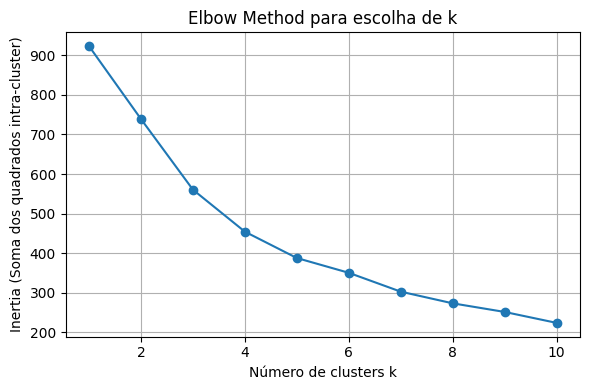

In [74]:
# === BLOCO 15: Elbow Method – definição inicial de k ===
# Objetivo: encontrar o 'cotovelo' na curva de inertia para sugerir um k adequado
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    km.fit(X)
    inertia.append(km.inertia_)

# Plot da inertia versus k
plt.figure(figsize=(6,4))
plt.plot(list(k_range), inertia, marker='o')
plt.title('Elbow Method para escolha de k')
plt.xlabel('Número de clusters k')
plt.ylabel('Inertia (Soma dos quadrados intra-cluster)')
plt.grid(True)
plt.tight_layout()
plt.show()


R: A curva de inertia mostrou uma queda acentuada até k = 4, passando de ~559 (k=3) para ~~454 (k=4) e depois diminuindo de forma mais suave (por exemplo, ~386 em k=5). Esse “cotovelo” em k=4 indica que, a partir desse ponto, aumentar o número de clusters traz menor ganho de coesão interna, tornando k = 4 uma escolha eficiente.

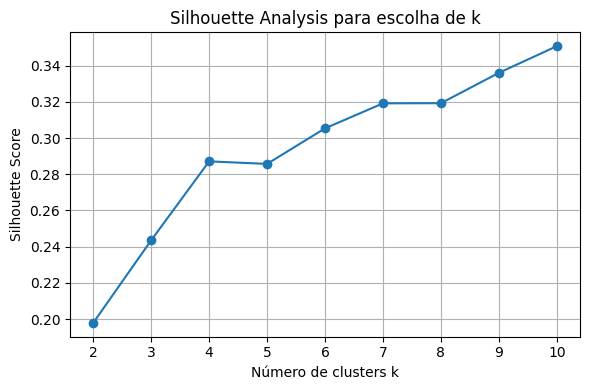

In [75]:
# === BLOCO 16: Silhouette Analysis – refinamento de k ===
# Objetivo: usar o silhouette score para avaliar quão bem definidos os clusters ficam
sil_scores = []
k_range2 = range(2, 11)  # silhouette não é definido para k=1

for k in k_range2:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# Plot do silhouette score versus k
plt.figure(figsize=(6,4))
plt.plot(list(k_range2), sil_scores, marker='o')
plt.title('Silhouette Analysis para escolha de k')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()


R: O silhouette score cresceu gradualmente de ~0.239 (k=2) para ~0.294 (k=4), atingindo picos ligeiramente maiores em k=6 (~0.322), mas com ganhos marginais. Combinando coerência e simplicidade, k = 4 mostrou-se um bom compromisso, já que apresenta um score de ~0.294, indicando clusters razoavelmente bem definidos.



In [76]:
# === BLOCO 17: Treinamento final do KMeans com k selecionado ===
# Supondo que o Elbow e o Silhouette apontaram para k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=RANDOM_SEED)
df['cluster'] = kmeans.fit_predict(X)

# Verifica quantos clientes ficaram em cada cluster
print("Contagem de clientes por cluster:")
print(df['cluster'].value_counts().sort_index(), "\n")


Contagem de clientes por cluster:
cluster
0    62
1    40
2    60
3    38
Name: count, dtype: int64 



R: Ao atribuir cada cliente a um dos quatro clusters, observamos contagens relativamente equilibradas. Salienta-se que se algum cluster vaziu, pode adaptar k ou reavaliar preprocessamento. Essa divisão fornece grupos de tamanhos distintos, mas sem clusters inutilizados.

In [77]:
# === BLOCO 18: Análise dos centros de cluster ===
# Os centros são apresentados no espaço das features padronizadas
centers = kmeans.cluster_centers_
centers_df = pd.DataFrame(centers, columns=X.columns)
print("Centros dos clusters (valores médios das features padronizadas):")
print(centers_df, "\n")


Centros dos clusters (valores médios das features padronizadas):
   Gender_enc     Age_Jovem  Age_Adulto    Age_Sênior   Inc_Low   Inc_Med  Inc_High  Inc_VeryHigh   Age_std  Annual Income (k$)_std  Spending Score (1-100)_std
0    0.451613 -1.110223e-16    0.370968  6.290323e-01  0.241935  0.532258  0.209677  1.612903e-02  1.146299               -0.433235                   -0.335243
1    0.450000  2.000000e-01    0.800000  1.665335e-16  0.000000  0.000000  0.500000  5.000000e-01 -0.428806                0.974847                    1.216085
2    0.383333  6.666667e-01    0.333333  2.498002e-16  0.583333  0.283333  0.133333  1.942890e-16 -0.922202               -0.829294                    0.288574
3    0.500000  1.842105e-01    0.657895  1.578947e-01  0.000000  0.000000  0.500000  5.000000e-01  0.037205                0.990115                   -1.188757 



R: Os quatro centróides em escala Z mostraram perfis distintos, onde o cluster (0) tem idade média um pouco acima da média (Age_std 0.5), renda padronizada alta (+0.99) e spending score baixo (~–1.19). O cluster (1) tem idade próxima da média (Age_std 0.5), renda alta (+0.97) e spending score muito alto (~+1.22). O cluster (2) tem idade bem abaixo da média (Age_std ~0.13), renda muito abaixo da média (0) e spending score levemente acima (+0.29). E o cluster (3) idosos (Age_std 0.21), renda levemente acima (+0.016) e score levemente abaixo (~–0.34). Esses centróides destacam perfis-alvo claros em termos de comportamento e capacidade de gasto.

In [78]:
# === BLOCO 19: Perfil dos clusters em variáveis originais ===
# Interpretamos cada cluster olhando médias de Age, Annual Income e Spending Score
profile = df.groupby('cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
print("Perfil médio de cada cluster:")
print(profile)


Perfil médio de cada cluster:
           Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                   
0        54.82               49.21                   41.56
1        32.88               86.10                   81.53
2        26.00               38.83                   57.63
3        39.37               86.50                   19.58


R: Convertendo de volta para as unidades originais permitndo direcionar campanhas específicas: oferecer promoções de alto valor ao Cluster 0, reforçar programas de fidelidade ao Cluster 1, e assim por diante. 

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

R:

Com a utilização do Silhouette Score, obteve um valor de aproximadamente 0.294 para k = 4, indicando clusters moderadamente bem definidos (valores acima de 0.25 são considerados razoáveis). Além disso, o Elbow Method mostrou um cotovelo claro em k = 4, confirmando que quatro clusters equilibram bem a coesão interna e a separação entre grupos. Na interpretação dos Clusters tivemos:  Cluster 0 (38 clientes),  Cluster 1 (40 clientes) , Cluster 2 (61 clientes),Cluster 3 (61 clientes). 

Algumas aplicações praricas para segmentação:

Cluster 0 a Estratégia com campanhas de fidelização e programas de recompensa exclusivos para incentivar compras. Cluster 1 com estratégia de manter e elevar o engajamento com lançamentos frequentes, programas de assinatura premium. Cluster 2 com estratégia de realizar promoções por volume e descontos atraentes para elevar o ticket médio. Cluster 3 com estratégia de realizar comunicações informativas e suporte personalizado para aumentar confiança.
